<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 09: Diferenciaci&oacute;n num&eacute;rica</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 19 de junio, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>Diferencias</li>
        <li>Resolver ecuaciones diferenciales</li>
        <li>Estabilididad</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.6
Estilo usado: <function context at 0x7f20e79d9590>


# Diferencias forward, backward, y central

Sea $h>0$ y $f$ una funci&oacute;n dada.
<ul>
    <li>Diferencia forward: $D_+(f,x_0,h) := \frac{f(x_0+h)-f(x_0)}{h}$, $|f'(x_0)-D_+(f,x_0,h)| = \mathcal{O}(h)$ si $f\in C^2$</li>
    <li>Diferencia backward: $D_-(f,x_0,h) := \frac{f(x_0)-f(x_0-h)}{h}$, $|f'(x_0)-D_-(f,x_0,h)| = \mathcal{O}(h)$ si $f\in C^2$</li>
    <li>Diferencia central: $D_c(f,x_0,h) := \frac{f(x_0+h)-f(x_0-h)}{2h}$, $|f'(x_0)-D_c(f,x_0,h)| = \mathcal{O}(h^2)$ si $f\in C^3$</li>
</ul>
Nota que la diferencia central converge m&aacute;s r&aacute;pido si $f$ es m&aacute;s regular (eso significa $C^3$ en vez de $C^2$).

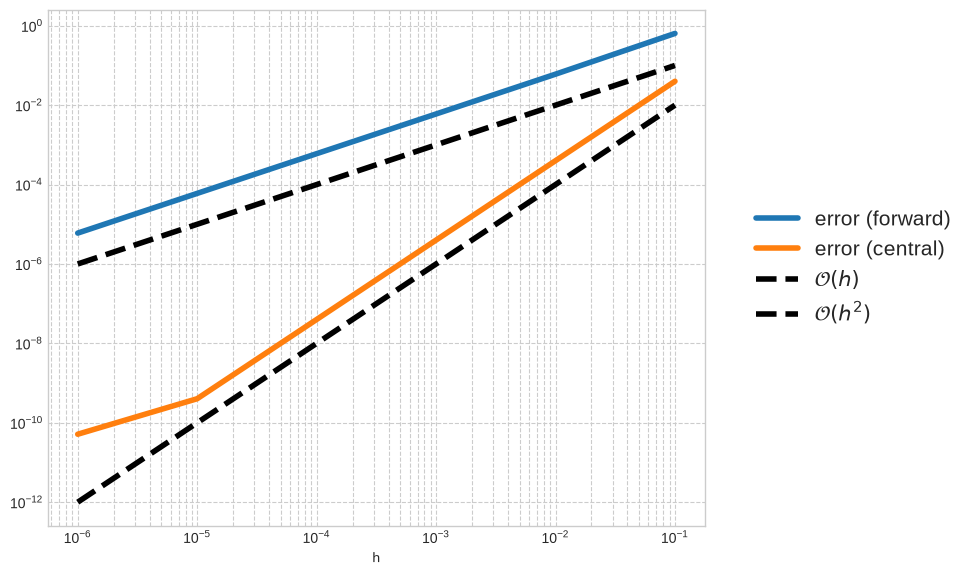

In [2]:
# funcion suave
f = lambda x: x**4
fp = lambda x: 4*x**3

# Diferencias forward y central
Nforward = lambda x, h: (f(x + h) - f(x)) / h
Ncentral = lambda x, h: (f(x+h)-f(x-h))/(2*h)

# Parametros
x0 = 1.0
M = fp(x0)
h = 10.0 ** np.arange(-6, 0) # generar sucesion h =  10^{-k}

# errores absolutors
err_forward = np.abs(M - Nforward(x0, h))
err_central = np.abs(M - Ncentral(x0, h))

# Graficar
plt.figure(figsize=(10, 6))
plt.loglog(h, err_forward, label='error (forward)', linewidth=4)
plt.loglog(h, err_central, label='error (central)', linewidth=4)
plt.loglog(h, h**1, '--k', label='$\\mathcal{O}(h)$', linewidth=4)
plt.loglog(h, h**2, '--k', label='$\\mathcal{O}(h^2)$', linewidth=4)

# formato
plt.rc('font', size=15)
plt.xlabel('h')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

En el ejemplo veremos la convergencia esperada en la teoria. Para $h$ m&aacute;s y m&aacute;s pequeno, se pierde la estabilidad (lo estudiaremos m&aacute;s abajo). 

Que pasar&aacute; si usamos una funci&oacute;n $f$ que es menos regular? Por ejemplo $f(x) = x^{2.001}$ para $x\geq 0$ y $f(x) = 0$ para $x<0$ es $C^2$ pero la tercera derivada no existe en $x=0$. 

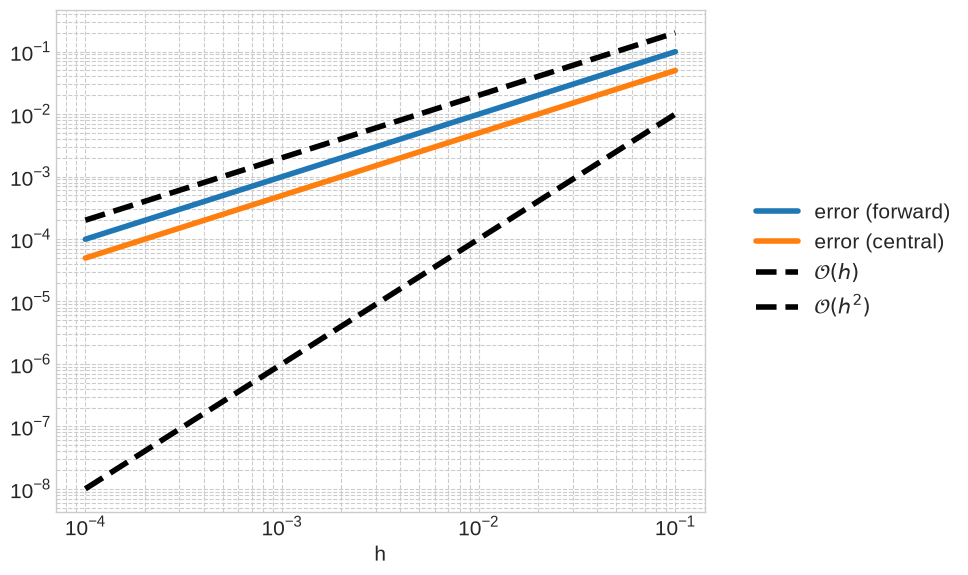

In [3]:
# funcion que no es 3 veces derivable en x==0
f = lambda x: np.heaviside(x,1)*abs(x)**(2.001)
fp = lambda x: np.heaviside(x,1)*abs(x)**(1.001) # su derivada

# Diferencias forward y central
Nforward = lambda x, h: (f(x + h) - f(x)) / h
Ncentral = lambda x, h: (f(x+h)-f(x-h))/(2*h)

# Parametros
x0 = 0.0
M = fp(x0)
h = 10.0 ** np.arange(-4, 0) # generar sucesion h =  2^{-k}

# errores absolutors
err_forward = np.abs(M - Nforward(x0, h))
err_central = np.abs(M - Ncentral(x0, h))

# Graficar
plt.figure(figsize=(10, 6))
plt.loglog(h, err_forward, label='error (forward)', linewidth=4)
plt.loglog(h, err_central, label='error (central)', linewidth=4)
plt.loglog(h, 2*h**1, '--k', label='$\\mathcal{O}(h)$', linewidth=4)
plt.loglog(h, h**2, '--k', label='$\\mathcal{O}(h^2)$', linewidth=4)

# formato
plt.rc('font', size=15)
plt.xlabel('h')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

Observamos que ambas aproximaciones convergen con orden $2$ (es decir los errores se comparten como $\mathcal{O}(h)$ para $h\to 0$.

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    La extrapolaci&oacute;n de Richardson permite derivar nuevas f&oacute;rmulas para aproximar derivadas con ordenes m&aacute;s altos: 
    Por ejemplo, si extrapolamos la diferencia forward: 
    $$
    R(h) = 2D_+(f,x_0,h/2)-D_+(f,x_0,h), \qquad
    |f'(x_0)-R(h)| = \mathcal{O}(h^2), \quad \text{si } f\in C^3.
    $$
    Implementa $R(h)$ y demuestra num&eacute;ricamante orden de convergencia. Que pasa con el orden si $f$ no es $C^3$? 
    Compara la aproximaciones $R(h)$ con la diferencia central. 
</div>

In [4]:
# Tu codigo va aqui


# Estabilidad

Todas aproximaciones a derivadas que est&aacute;n basadas en tomar diferencias de 2 n&uacute;meros cercanos, usualmente $f(x_0\pm h)$ y/o $f(x_0)$ tienen un problema fundamental que se observa cuando $h\to 0$. Por ejemplo, 
$$
|f'(x_0)-D_+(f,x_0,h)| \leq C_1 h \|f''\|_{\infty,[a,b]} + C_2\frac{\varepsilon}{h}
$$
donde $C_1,C_2>0$ son constantes y $\varepsilon>0$ representa la precisi&oacute;n de la m&aacute;quina (precisamente los errores de redodendeo que se hace al evaluar la funci&oacute;n $f$).

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Para la diferencia forward prueba graficamente que se observa el compartamiento descrito en la estimaci&oacute;n del error.
    Considera lo mismo para la diferencia central (se cambia $h$ a $h^2$ y la segunda derivada a la tercera derivada en el primer t&eacute;rmino de la estimaci&oacute;n
</div>

In [5]:
# tu codigo



## Desarrollo de f&oacute;rmula estable para funciones anal&iacute;ticas

Si $f$ es una funci&oacute;n anal&iacute;tica, es decir, $f$ es derivable como funci&oacute;n $f\colon \mathbb{C}\to\mathbb{C}$ entonces podemos desarrollar una aproximaci&oacute;n estable:

Sea $h>0$, $x_0\in\mathbb{R}$. Consideramos el desarrollo
$$
f(x_0 + \mathrm{i}h) = f(x_0) + \mathrm{i}hf'(x_0) - \frac{h^2}2f''(x_0) - \frac{\mathrm{i}h^3}{6}f'''(x_0) \cdots
$$
donde $\mathrm{i}$ denota la unidad imaginaria. Tomando la parte imaginario y resolviendo para $f'(x_0)$  nos lleva a 
$$
f'(x_0) = \frac{\mathrm{Im}(f(x_0+\mathrm{i}h))}{h} + \mathcal{O}(h^2)
$$

En Python podemos la unidad imaginaria se representa con <code>j</code> y la parte imaginaria podemos sacar usando el comando <code>np.imag(\<valor\>)</code>

Un n&uacute;mero complejo $a+\mathrm{i}b$ se escribe en Python (NumPy) como <code>a+bj</code>

In [6]:
# Definimos funciones como siempre
f = lambda x: x**2 + 2*x + 2

# Evaluar la funcion
print(f(3 + 4j))  # Resultado: 1+32j

# Parte real/imaginaria
print('Parte real      : ',np.real(f(3+4j)))
print('Parte imaginaria: ',np.imag(f(3+4j)))

(1+32j)
Parte real      :  1.0
Parte imaginaria:  32.0


<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Implementa la aproximaci&oacute;n estable y compara con la diferencia central. 
    Verifica la estabilidad num&eacute;ricamente para varias funciones cuando $h\to 0$.
    Que pasa si la funci&oacute;n no es anal&iacute;tica?
</div>

In [7]:
# Espacio para tu codigo:




M&aacute;s informaci&oacute;n sobre diferenciaci&oacute;n estable se encuentran en el &aacute;rticulo: **USING COMPLEX VARIABLES TO ESTIMATE DERIVATIVES OF REAL FUNCTIONS** de los autores *William Squire* y *George Trapp* en la revista *SIAM REVIEW*, Vol. 40, 1998. 

# Derivadas del segundo orden

Para aproximar $f''(x_0)$ podemos considerar el desarrollo de Taylor. Sea $h>0$, $x_0\in\mathbb{R}$, $f\in C^4$:
\begin{align*}
f(x_0+h) &= f(x_0) + h f'(x_0) + \frac{h^2}2 f''(x_0) + \frac{h^3}6 f'''(x_0) + \frac{h^4}{24} f^{(4)}(\xi_1), \\
f(x_0-h) &= f(x_0) - h f'(x_0) + \frac{h^2}2 f''(x_0) - \frac{h^3}6 f'''(x_0) + \frac{h^4}{24} f^{(4)}(\xi_2). 
\end{align*}
Sumando y resolviendo para la segunda derivada, vemos que
$$
f''(x_0) = \frac{f(x_0+h)+f(x_0-h)-2f(x_0)}{h^2} + \mathcal{O}(h^2)
$$

In [8]:
# Espacio para tu codigo:




# Ecuaciones diferenciales

Las aproximaciones num&eacute;ricas de derivadas sirven para definir m&eacute;todos para resolver ecuaciones diferenciales.
Consideramos el siguiente problema, dada una funci&oacute;n $f$, queremos encontrar la soluci&oacute;n $u$ a la ecuacion diferencial
\begin{align*}
-u''(x) + u(x) &= f(x) \quad\text{para } x\in (0,1), \\\
u(0) &= 0 = u(1).
\end{align*}
Consideramos ademas una particion uniforme en $N$ intervalos del intervalo $[0,1]$, $x_j := jh$ con $h = 1/N$. La soluci&oacute;n $u$ queremos aproximar en todos los puntos $x_j$. Si ocupamos la aproximaci&oacute;n de la segunda derivada, entonces obtenemos para $j=1,...,N-1$, 
\begin{align*}
-\frac{u(x_{j+1})+u(x_{j-1})-2u(x_j)}{h^2} + u(x_j) = f(x_j)
\end{align*}
y $u(x_0) = u(0) = 0$, $u(x_N) = u(1) = 0$.

*Nota:* El m&eacute;todo descrito se llama m&eacute;todo de **diferencias finitas** y es muy popular para resolver ecuaciones diferenciales. 

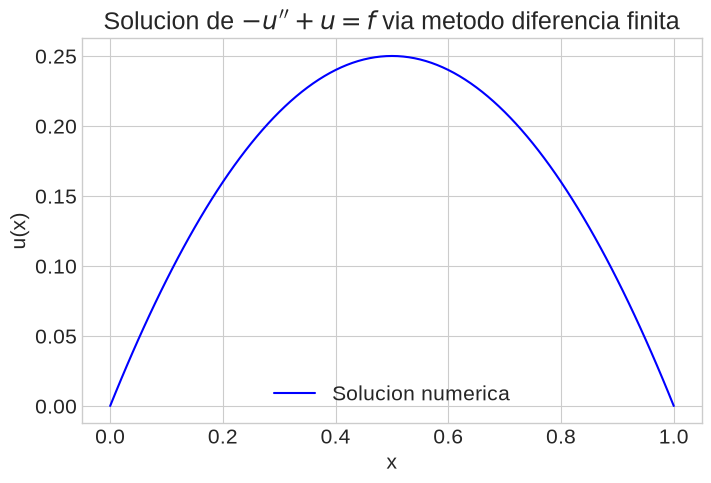

In [9]:
# funcion f
f = lambda x: (2+x-x**2)    # la solucion exacta es u(x) = x*(1-x)

# Malla (particion uniforme)
N = 100               
x0, xN = 0.0, 1.0     # intervalo
y0, yN = 0.0, 0.0     # condiciones de contorno

x = np.linspace(x0, xN, N + 1)
h = (xN - x0) / N

# resolvemos un sistema lineal
A = np.zeros((N + 1, N + 1))
b = np.zeros(N + 1)

# Incluimos condiciones de contorno en la matriz y el lado derecho
A[0, 0] = 1
b[0] = y0

A[N, N] = 1
b[N] = yN

# Asemblear la matriz ( j=1,...,N-1)
for i in range(1, N):
    A[i, i-1] = -(1 / h**2)                 
    A[i, i]   = 2 / h**2 + 1        
    A[i, i+1] = -(1 / h**2)       
    b[i]      = f(x[i])            # lado derecho f(x_i)

# resolver
u = np.linalg.solve(A, b)

# 6. Plot the numerical solution
plt.figure(figsize=(8, 5))
plt.plot(x, u, 'b-', label='Solucion numerica')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Solucion de $-u\'\' + u = f$ via metodo diferencia finita')
plt.grid(True)
plt.legend()
plt.show()

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Modifica el c&oacute;digo arriba para resolver la ecuaci&oacute;n diferencial
    \begin{align*}
    -\alpha u''(x) + u'(x) &= 1, \quad x\in(0,1), \\
    u(0) &= 0 = u(1).
    \end{align*}
    donde $\alpha>0$. Usa la diferencia central para aproximar $u'(x_j)$. 
    <br>
    Grafica la soluci&oacute;n para $\alpha = 0.1$, $\alpha=0.01$ y $\alpha=0.001$.
    Que se observa cuando $\alpha$ se hace mas pequeno? 
    Sirve considerar una malla mas fina, digamos con $N=1000$?
</div>

In [10]:
# Espacio para tu codigo:

